# Discrepancy Computations for Extra Models

The point of this notebook is to run and save log prob curvature computations on the texts from the GPT-J, GPT-Neo, and GPT-2 runs using the GPT-2-Medium, GPT-2-Large, and GPT-2-XL models in a way that is consistent with detectgpt.ipynb

In [27]:
import os
import re
import json
import torch
import random
from tqdm import tqdm
from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoModelForSeq2SeqLM, AutoTokenizer
from datasets import Dataset
from IPython.display import display

In [28]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


## Define Functions

### Importing / Reading Functions

In [29]:
def load_and_validate_jsonl_original(file_path):
    EXPECTED_KEYS = {"text", "id", "model"}
    data = []
    with open(file_path, "r") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                item = json.loads(line)
            except json.JSONDecodeError as e:
                raise ValueError(f"Line {line_number} is not valid JSON: {e}")
            if not isinstance(item, dict):
                raise ValueError(f"Line {line_number} is not a dictionary.")
            if set(item.keys()) != EXPECTED_KEYS:
                raise ValueError(
                    f"Line {line_number} has unexpected keys: {set(item.keys())}. Expected: {EXPECTED_KEYS}"
                )
            data.append(item)

    if len(data) != 200:
        raise ValueError(f"Expected 200 items in the file, but found {len(data)}.")

    return data

In [30]:
def load_and_validate_jsonl_perturbations(file_path):
    data = []
    with open(file_path, "r") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                row = json.loads(line)
            except json.JSONDecodeError as e:
                raise ValueError(f"Line {line_number} is not valid JSON: {e}")
            if not isinstance(row, list):
                raise ValueError(f"Line {line_number} is not a list.")
            if len(row) != 200:
                raise ValueError(f"Line {line_number} does not contain 200 elements (found {len(row)}).")
            data.append(row)

    if len(data) != 100:
        raise ValueError(f"Expected 100 lines (outer list elements), but found {len(data)}.")

    return data

### Computation Functions

In [31]:
def get_ll(text, computation_model, computation_tokenizer):
    with torch.no_grad():
        tokenized = computation_tokenizer(text, return_tensors="pt", truncation=True, max_length=1024).to(DEVICE)
        labels = tokenized.input_ids
        output = computation_model(**tokenized, labels=labels)
        avg_ll = -output.loss.item()
    return avg_ll

def get_lls(texts, computation_model, computation_tokenizer):
    return [get_ll(text, computation_model, computation_tokenizer) for text in texts]

In [32]:
def compute_detectgpt_discrepancy(log_probs_per_text_base: list,
                                log_probs_per_text_transformed: list,
                                normalization: bool=False) -> list:
    """
    Compute the DetectGPT discrepancy metric for each of the n_samples texts. Computed for n_perturbations perturbations.

    Args:
        log_probs_per_text_base (list): original log probability of each text
        log_probs_per_text_transformed (list): list of size n_samples where each element is a list of the n_perturbations perturbed log probs
        normalization (bool): True if you want to normalize the discrepancy scores, False otherwise

    Returns:
        discrepancy_scores (list): list of discrepancy values (d) for the n_samples texts
    """
    n_samples = len(log_probs_per_text_base) 
    discrepancy_scores = []

    for i in range(n_samples):
        original_log_prob = log_probs_per_text_base[i]
        perturbed_log_probs = log_probs_per_text_transformed[i] # List of perturbed log probs

        # Compute mean log probability of the perturbed texts
        mu = np.mean(perturbed_log_probs)  

        # Compute discrepancy
        discrepancy_score_unormalized = original_log_prob - mu
        if normalization:
            # Normalize
            sigma = np.std(perturbed_log_probs)
            discrepancy_score_normalized = discrepancy_score_unormalized / sigma if sigma > 0 else discrepancy_score_unormalized
            discrepancy_scores.append(discrepancy_score_normalized)
        else:
            discrepancy_scores.append(discrepancy_score_unormalized)
    
    return discrepancy_scores

In [33]:
def compare_log_prob(original_texts, all_perturbed_texts, computation_model, computation_tokenizer, n_perturbation=100):
    """
    Compares log probs of original text vs list of JSONs perturbed texts
    Args:

    Returns:
        log_probs_per_text_base is a list of length num_samples, each entry being the log prob of the corresponding original text
        log_probs_per_text_pert is a list of length num_samples, each entry being a list of length num_pertubations, each entry being the log prob of the corresponding perturbed text

    """
    list_original_texts = [" ".join(original_texts[j]["text"].split()) for j in range(len(original_texts))] # Truncate text to max_length, returns list of strings as before
    
    # Initialise list to store log prob of each perturbed JSON
    
    log_probs_per_text_pert = []

    # Get num_samples
    num_samples = len(list_original_texts)

    # Calculate log prob for original text in batch
    log_probs_per_text_base = get_lls(list_original_texts, computation_model, computation_tokenizer)

    # Iterate 
    for perturbation_idx in tqdm(range(n_perturbation)):

        # Get the JSON file
        perturbed_texts = all_perturbed_texts[perturbation_idx]

        # Calculate log prob
        log_probs_per_text_tran = get_lls(perturbed_texts, computation_model, computation_tokenizer)

        # Organize results by original text
        for j in range(num_samples):
            if perturbation_idx == 0:
                log_probs_per_text_pert.append([])
            log_probs_per_text_pert[j].append(log_probs_per_text_tran[j])
        
    return log_probs_per_text_base, log_probs_per_text_pert

### Saving / Writing Functions

In [34]:
# Function to save the results in the correct .jsonl format

def save_results_jsonl(data, file_name_base, n_samples, max_length, n_perturbations, generation_model_name, perturbation_model_name, computation_model_name):
    """
    Saves a dataset in JSONL format in a structured directory.
    
    Parameters:
        data (list): List of results to be saved.
        file_name_base (str): Base name for the file.
    """
    BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    file_name = (
    f"{file_name_base}__{n_samples}_Samples__{max_length}_Max_Length__"
    f"{n_perturbations}_Perturbations__Generated_By_{generation_model_name}__"
    f"Perturbed_By_{perturbation_model_name}__Scored_By_{computation_model_name}__"
    f"{timestamp}.jsonl"
    )  # CHANGE THIS TO CONTROL THE FORMAT OF THE FILE NAME
    file_relative_path = os.path.join("Results", file_name)
    # file_path = os.path.join(BASE_DIR, file_relative_path)
    file_path = file_relative_path
    
    # Ensure directory exists
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    
    # Save the dataset in JSONL format
    with open(file_path, "w") as f:
        json.dump(data, f, indent=2)
    
    print(f"Dataset saved at: {file_path}")

### Plotting Functions

In [35]:
def get_roc_metrics(discrepancy_scores_human, discrepancy_scores_ai):
    fpr, tpr, _ = roc_curve([0] * len(discrepancy_scores_human) + [1] * len(discrepancy_scores_ai), discrepancy_scores_human + discrepancy_scores_ai)
    roc_auc = auc(fpr, tpr)
    return fpr.tolist(), tpr.tolist(), float(roc_auc)

In [36]:
def plot_histogram(discrepancy_scores_human, discrepancy_scores_ai, model_name):
    plt.hist(discrepancy_scores_human, bins='auto', alpha=0.5, label='Human', edgecolor='black')
    plt.hist(discrepancy_scores_ai, bins='auto', alpha=0.5, label='AI', edgecolor='black')

    plt.xlabel(f'Discrepancy scores')
    plt.ylabel('Frequency')
    plt.title(f'Computation model: {model_name}')
    plt.legend()
    plt.show()

In [37]:
def roc_curves(fpr,tpr, model_name):
    plt.clf()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves ({model_name})')
    plt.show()

### Other Functions

In [38]:
# Memory management utilities
def clear_cuda_cache():
    """Clear CUDA cache to free up memory."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Import Data

### Original Human Texts Pre-Processing

Set Dictionaries

In [44]:
# Set a dictionary of models to iterate over
orig = [["EleutherAI", "gpt-j-6B"], ["EleutherAI", "gpt-neo-2.7B"], ["openai-community", "gpt2"]]

# Create a dictionary to store the text outputs
orig_human_texts = {}

Import, Structure, and Format Human Data

In [45]:
# Set the file path

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
FILE_PATH = "Data/EdinburghNLP___xsum/default/1.2.0/40db7604fedb616a9d2b0673d11838fa5be8451c/xsum-test.arrow"  # CHANGE THIS TO THE PATH OF THE HUMAN-GENERATED TEXT FILE

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"File not found: {FILE_PATH}")

# Set the parameters
sample_size_original = 200
max_length_original = 200

# Load the dataset
dataset = Dataset.from_file(FILE_PATH)

# Pre-process the dataset to obtain the desired structure and format
dataset = dataset.select(range(sample_size_original))   # Keep only the first 200 samples
df = dataset.to_pandas()
df = df.rename(columns={"document": "text"}).drop(columns=["summary"])
df["model"] = "human"

Define Functions to Truncate the Data Correctly

In [46]:
def set_generation_model(community_and_name):
    CACHE_DIR = "/tmp/huggingface"

    GENERATION_MODEL_NAME = community_and_name[0] + "/" + community_and_name[1]
    # Model list (all tested)

    # openai-community/gpt2
    # openai-community/gpt2-medium
    # openai-community/gpt2-large
    # openai-community/gpt2-xl

    # EleutherAI/gpt-neo-2.7B
    # EleutherAI/gpt-j-6B
    # EleutherAI/gpt-neox-20b

    generation_model_kwargs = {}
    if 'gpt-j' in GENERATION_MODEL_NAME or 'neox' in GENERATION_MODEL_NAME:
        generation_model_kwargs.update(dict(torch_dtype=torch.float16))
    if 'gpt-j' in GENERATION_MODEL_NAME:
        generation_model_kwargs.update(dict(revision='float16'))

    # Load model
    generation_model = AutoModelForCausalLM.from_pretrained(GENERATION_MODEL_NAME, **generation_model_kwargs, cache_dir=CACHE_DIR)

    # Load tokenizer
    generation_tokenizer = AutoTokenizer.from_pretrained(GENERATION_MODEL_NAME, cache_dir=CACHE_DIR)

    generation_tokenizer.model_max_length = 1024 # what is the impact for generation ??

    if generation_tokenizer.pad_token is None:
        generation_tokenizer.pad_token = generation_tokenizer.eos_token
    generation_tokenizer.pad_token_id = generation_tokenizer.eos_token_id

    return CACHE_DIR, GENERATION_MODEL_NAME, generation_model, generation_tokenizer

In [47]:
def get_text(df, community_and_name, generation_tokenizer):
    df_new = df.copy()
    df_new["text"] = df_new["text"].apply(lambda x: generation_tokenizer.convert_tokens_to_string(generation_tokenizer.tokenize(x)[:max_length_original]) \
                                if len(generation_tokenizer.tokenize(x)) > max_length_original else x)    # Truncate the text to a maximum length of 200 tokens
    orig_human_texts[community_and_name[1]] = df_new.to_dict(orient="records")

Truncate the Data Correctly and Individually for Each Model

In [48]:
for lst in orig:
    CACHE_DIR, GENERATION_MODEL_NAME, generation_model, generation_tokenizer = set_generation_model(lst)
    get_text(df, lst, generation_tokenizer)

print(len(orig_human_texts))

Some weights of the model checkpoint at EleutherAI/gpt-j-6B were not used when initializing GPTJForCausalLM: ['transformer.h.0.attn.bias', 'transformer.h.0.attn.masked_bias', 'transformer.h.1.attn.bias', 'transformer.h.1.attn.masked_bias', 'transformer.h.10.attn.bias', 'transformer.h.10.attn.masked_bias', 'transformer.h.11.attn.bias', 'transformer.h.11.attn.masked_bias', 'transformer.h.12.attn.bias', 'transformer.h.12.attn.masked_bias', 'transformer.h.13.attn.bias', 'transformer.h.13.attn.masked_bias', 'transformer.h.14.attn.bias', 'transformer.h.14.attn.masked_bias', 'transformer.h.15.attn.bias', 'transformer.h.15.attn.masked_bias', 'transformer.h.16.attn.bias', 'transformer.h.16.attn.masked_bias', 'transformer.h.17.attn.bias', 'transformer.h.17.attn.masked_bias', 'transformer.h.18.attn.bias', 'transformer.h.18.attn.masked_bias', 'transformer.h.19.attn.bias', 'transformer.h.19.attn.masked_bias', 'transformer.h.2.attn.bias', 'transformer.h.2.attn.masked_bias', 'transformer.h.20.attn.bi

3


### All Texts Together

In [49]:
# Note that the original texts are each a list of dictionaries,
# with the outer list having 200 elements,and the dictionaries each having 3 keys: "text", "id", and "model".

# Note that the perturbed texts are each a list of lists,
# with the outer list having 100 element (corresponding to 100 different perturbations), and the inner lists having 200 elements each (corresponding to 200 samples).


# Dictionary to store the original texts
original_texts = {}
# Dictionary to store the perturbed texts
perturbed_texts = {}

# --------------------------------------------------------------
# Import the GPT-J texts
# Import the human texts
original_texts['human_from_gpt_j'] = orig_human_texts[orig[0][1]]
perturbed_texts['human_from_gpt_j'] \
    = load_and_validate_jsonl_perturbations("/workspace/Data/Perturbations/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__20250318_170716.jsonl")

# Import the GPT-J generated texts
original_texts['gpt_j_generated'] \
    = load_and_validate_jsonl_original("/workspace/Data/AI-Generated/XSUM__Generated_By_EleutherAI/gpt-j-6B__200_Samples__200_Max_Length__20250318_162510.jsonl")
perturbed_texts['gpt_j_generated'] \
    = load_and_validate_jsonl_perturbations("/workspace/Data/Perturbations/XSUM_AI__200_Samples__200_Max_Length__100_Perturbations__Generated_By_EleutherAI/gpt-j-6B__Perturbed_By_google-t5/t5-3b__20250318_174630.jsonl")


# --------------------------------------------------------------
# Import the GPT-Neo texts
# Import the human texts
original_texts['human_from_gpt_neo'] = orig_human_texts[orig[1][1]]
perturbed_texts['human_from_gpt_neo'] \
    = load_and_validate_jsonl_perturbations("/workspace/Data/Perturbations/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__20250318_192823.jsonl")

# Import the GPT-Neo generated texts
original_texts['gpt_neo_generated'] \
    = load_and_validate_jsonl_original("/workspace/Data/AI-Generated/XSUM__Generated_By_EleutherAI/gpt-neo-2.7B__200_Samples__200_Max_Length__20250318_185323.jsonl")
perturbed_texts['gpt_neo_generated'] \
    = load_and_validate_jsonl_perturbations("/workspace/Data/Perturbations/XSUM_AI__200_Samples__200_Max_Length__100_Perturbations__Generated_By_EleutherAI/gpt-neo-2.7B__Perturbed_By_google-t5/t5-3b__20250318_201114.jsonl")


# --------------------------------------------------------------
# Import the GPT-2 texts
# Import the human texts
original_texts['human_from_gpt_2'] = orig_human_texts[orig[2][1]]
perturbed_texts['human_from_gpt_2'] \
    = load_and_validate_jsonl_perturbations("/workspace/Data/Perturbations/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__20250319_102910.jsonl")

# Import the GPT-3 generated texts
original_texts['gpt_2_generated'] \
    = load_and_validate_jsonl_original("/workspace/Data/AI-Generated/XSUM__Generated_By_openai-community/gpt2__200_Samples__200_Max_Length__20250319_095459.jsonl")
perturbed_texts['gpt_2_generated'] \
    = load_and_validate_jsonl_perturbations("/workspace/Data/Perturbations/XSUM_AI__200_Samples__200_Max_Length__100_Perturbations__Generated_By_openai-community/gpt2__Perturbed_By_google-t5/t5-3b__20250319_111548.jsonl")

## Compute Discrepancies

### Set Computation Parameters

In [50]:
PERTURBATION_MODEL_NAME = "google-t5/t5-3b"

NUM_SAMPLES = 200
MAX_LENGTH = 200
NUM_PERTURBATIONS = 100

NORMALIZATION = True

### Define Functions to Call for Each Model

Set Model

In [51]:
def set_computation_model(computation_model_name):
    CACHE_DIR = "/tmp/huggingface"
    COMPUTATION_MODEL_NAME = 'openai-community/' + computation_model_name
    # Model list (all tested)

    # openai-community/gpt2
    # openai-community/gpt2-medium
    # openai-community/gpt2-large
    # openai-community/gpt2-xl

    # EleutherAI/gpt-neo-2.7B
    # EleutherAI/gpt-j-6B
    # EleutherAI/gpt-neox-20b

    computation_model_kwargs = {}
    if 'gpt-j' in COMPUTATION_MODEL_NAME or 'neox' in COMPUTATION_MODEL_NAME:
        computation_model_kwargs.update(dict(torch_dtype=torch.float16))
    if 'gpt-j' in COMPUTATION_MODEL_NAME:
        computation_model_kwargs.update(dict(revision='float16'))

    # Load model
    computation_model = AutoModelForCausalLM.from_pretrained(COMPUTATION_MODEL_NAME, **computation_model_kwargs, cache_dir=CACHE_DIR)

    # Load tokenizer 
    computation_tokenizer = AutoTokenizer.from_pretrained(COMPUTATION_MODEL_NAME, cache_dir=CACHE_DIR)

    computation_tokenizer.model_max_length = 1024 

    if computation_tokenizer.pad_token is None:
        computation_tokenizer.pad_token = computation_tokenizer.eos_token
    computation_tokenizer.pad_token_id = computation_tokenizer.eos_token_id

    computation_model.to(DEVICE)
    print(DEVICE)

    return CACHE_DIR, COMPUTATION_MODEL_NAME, computation_model, computation_tokenizer

Compute Discrepancies

In [52]:
def create_dictionaries():
    # Dictionary to store the log probs of the original texts
    log_probs_original = {}
    # Dictionary to store the log probs of the perturbed texts
    log_probs_perturbed = {}

    # Dictionary to store the discrepancy scores
    discrepancies = {}

    # Dictionary to store all the results
    results = {}

    return log_probs_original, log_probs_perturbed, discrepancies, results

In [53]:
def compute_discrepancies(log_probs_original, log_probs_perturbed, discrepancies, results, computation_model, computation_tokenizer):
    clear_cuda_cache()

    for text in original_texts:
        log_probs_original[text], log_probs_perturbed[text] = compare_log_prob(original_texts[text], perturbed_texts[text], computation_model, computation_tokenizer, NUM_PERTURBATIONS)
        discrepancies[text] = compute_detectgpt_discrepancy(log_probs_original[text], log_probs_perturbed[text], normalization=True)

        results[text] = {}
        results[text]["log_probs_base"] = log_probs_original[text]
        results[text]["log_probs_transformed"] = log_probs_perturbed[text]
        results[text]["discrepancy_scores"] = discrepancies[text]

    return results

Save Results

In [54]:
def save_discrepancies(results, COMPUTATION_MODEL_NAME):
    for result in results:
        if 'human' in result:
            save_results_jsonl(results[result], "XSUM_Human", NUM_SAMPLES, MAX_LENGTH, NUM_PERTURBATIONS, "Human", PERTURBATION_MODEL_NAME, COMPUTATION_MODEL_NAME)
        elif 'gpt_j' in result:
            save_results_jsonl(results[result], "XSUM_AI", NUM_SAMPLES, MAX_LENGTH, NUM_PERTURBATIONS, "EleutherAI/gpt-j-6B", PERTURBATION_MODEL_NAME, COMPUTATION_MODEL_NAME)
        elif 'gpt_neo' in result:
            save_results_jsonl(results[result], "XSUM_AI", NUM_SAMPLES, MAX_LENGTH, NUM_PERTURBATIONS, "EleutherAI/gpt-neo-2.7B", PERTURBATION_MODEL_NAME, COMPUTATION_MODEL_NAME)
        elif 'gpt_2' in result:
            save_results_jsonl(results[result], "XSUM_AI", NUM_SAMPLES, MAX_LENGTH, NUM_PERTURBATIONS, "openai/gpt-2", PERTURBATION_MODEL_NAME, COMPUTATION_MODEL_NAME)
        else:
            print("Error: Model not found")

Plot Results

In [55]:
def plot_results(results):
    model_names = ['gpt_j', 'gpt_neo', 'gpt_2']

    for name in model_names:
        discrepancy_scores_human = results[f'human_from_{name}']["discrepancy_scores"]
        discrepancy_scores_ai = results[f'{name}_generated']["discrepancy_scores"]

        fpr,tpr,roc_auc = get_roc_metrics(discrepancy_scores_human, discrepancy_scores_ai)
        print(f"AUROC for {name.upper()}: {roc_auc:.3f}")

        plot_histogram(discrepancy_scores_human, discrepancy_scores_ai, name)
        roc_curves(fpr,tpr, name)

### Run the Code for Each of: Medium, Large, XL

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


cuda


100%|██████████| 100/100 [03:27<00:00,  2.08s/it]


Dataset saved at: Results/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2-medium__20250325_221445.jsonl
Dataset saved at: Results/XSUM_AI__200_Samples__200_Max_Length__100_Perturbations__Generated_By_EleutherAI/gpt-j-6B__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2-medium__20250325_221445.jsonl
Dataset saved at: Results/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2-medium__20250325_221445.jsonl
Dataset saved at: Results/XSUM_AI__200_Samples__200_Max_Length__100_Perturbations__Generated_By_EleutherAI/gpt-neo-2.7B__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2-medium__20250325_221445.jsonl
Dataset saved at: Results/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2-medium__202503

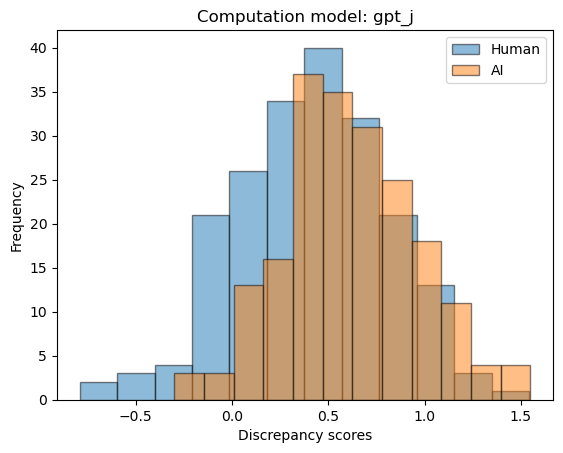

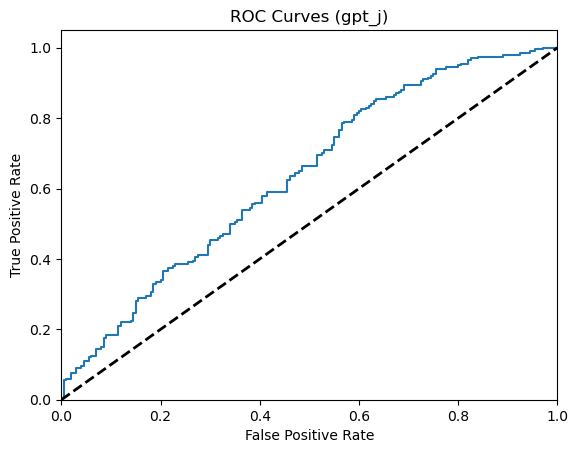

AUROC for GPT_NEO: 0.737


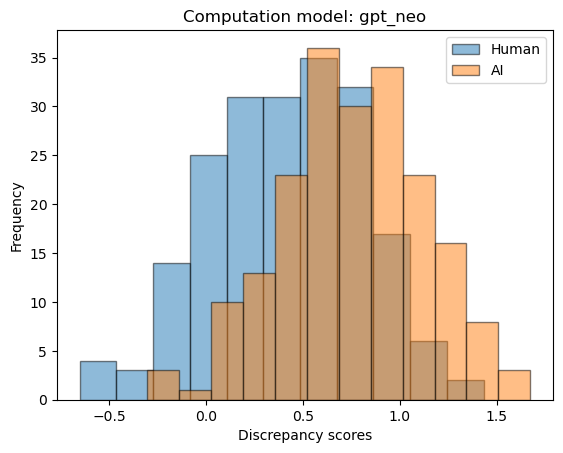

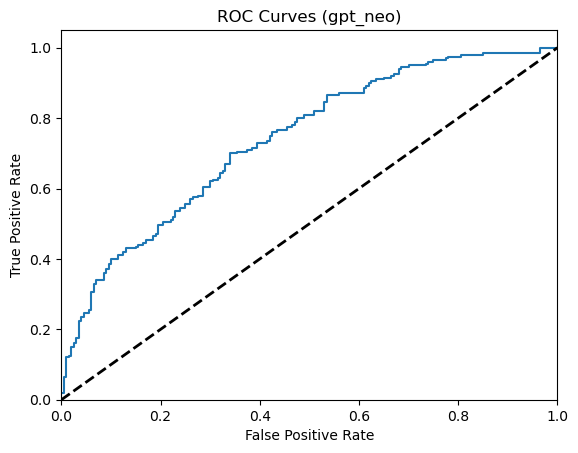

AUROC for GPT_2: 0.646


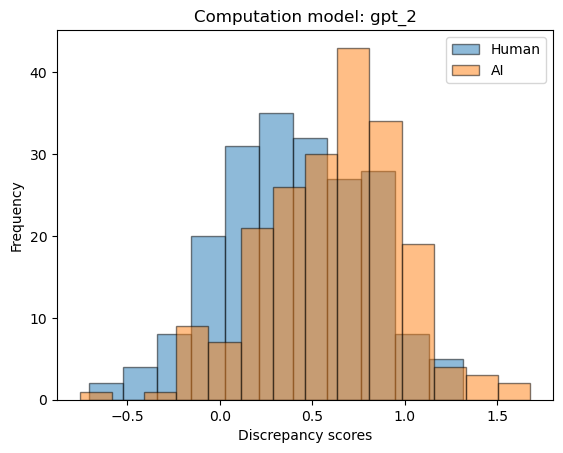

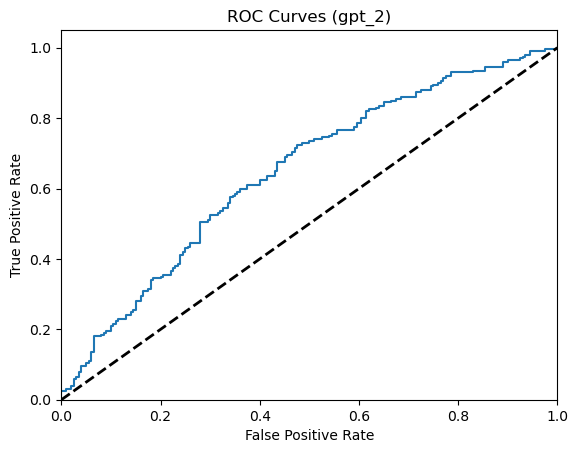

cuda


100%|██████████| 100/100 [05:49<00:00,  3.50s/it]


Dataset saved at: Results/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2-large__20250325_225107.jsonl
Dataset saved at: Results/XSUM_AI__200_Samples__200_Max_Length__100_Perturbations__Generated_By_EleutherAI/gpt-j-6B__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2-large__20250325_225107.jsonl
Dataset saved at: Results/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2-large__20250325_225107.jsonl
Dataset saved at: Results/XSUM_AI__200_Samples__200_Max_Length__100_Perturbations__Generated_By_EleutherAI/gpt-neo-2.7B__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2-large__20250325_225107.jsonl
Dataset saved at: Results/XSUM_Human__200_Samples__200_Max_Length__100_Perturbations__Generated_By_Human__Perturbed_By_google-t5/t5-3b__Scored_By_openai-community/gpt2-large__20250325_22

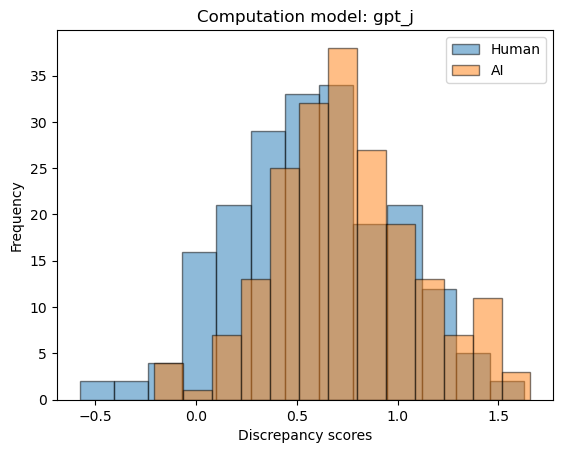

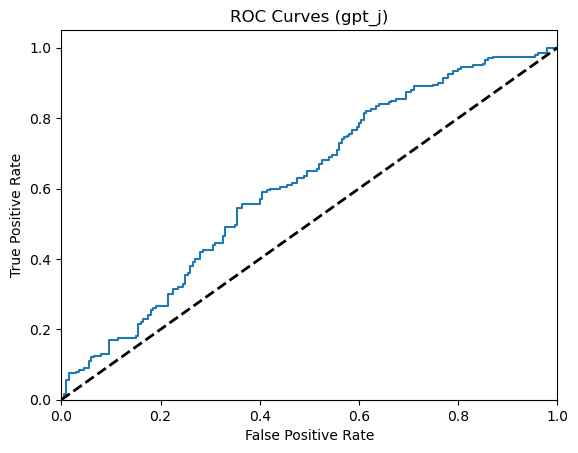

AUROC for GPT_NEO: 0.693


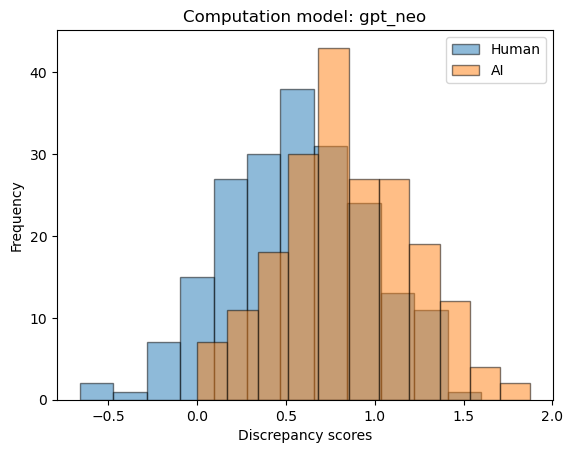

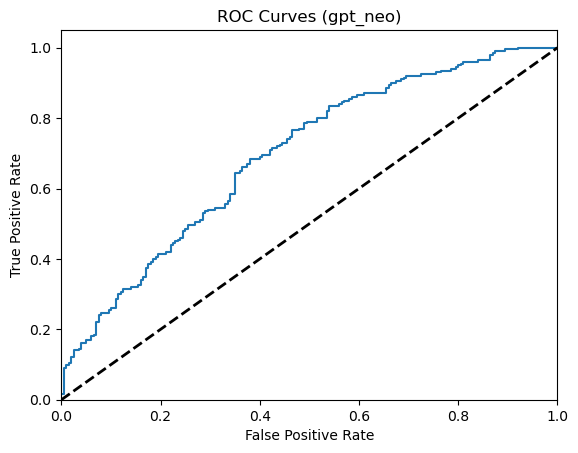

AUROC for GPT_2: 0.465


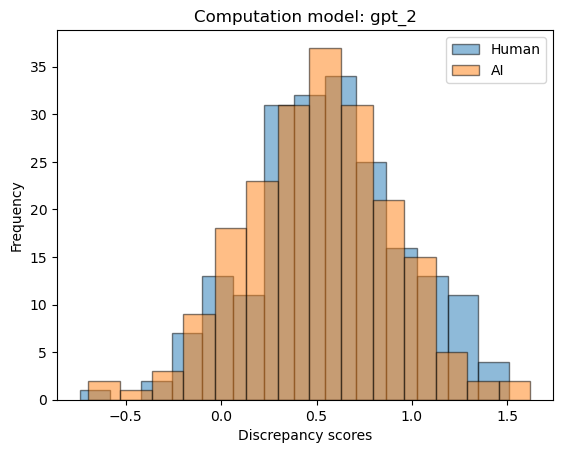

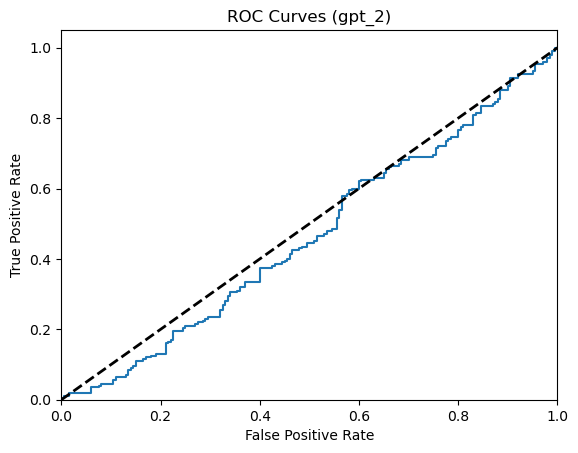

cuda


  1%|          | 1/100 [00:09<15:25,  9.35s/it]


KeyboardInterrupt: 

In [56]:
twos = ['gpt2-medium', 'gpt2-large', 'gpt2-xl']

for MODEL in twos:
    CACHE_DIR, COMPUTATION_MODEL_NAME, computation_model, computation_tokenizer = set_computation_model(MODEL)
    LOG_PROBS_ORIGINAL, LOG_PROBS_PERTURBED, DISCREPANCIES, RESULTS = create_dictionaries()
    RESULTS = compute_discrepancies(LOG_PROBS_ORIGINAL, LOG_PROBS_PERTURBED, DISCREPANCIES, RESULTS, computation_model, computation_tokenizer)
    save_discrepancies(RESULTS, COMPUTATION_MODEL_NAME)
    plot_results(RESULTS)